Saving food detect.v17-no_augs.yolov8.zip to food detect.v17-no_augs.yolov8 (1).zip
Dataset ready at: food detect.v17-no_augs.yolov8 (1)
Ultralytics 8.4.17 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=4, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.3, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=food detect.v17-no_augs.yolov8 (1)/data.yaml, degrees=10.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=True, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.0005, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.2, mode=train, model=yolov8s.pt, momentum=0.93

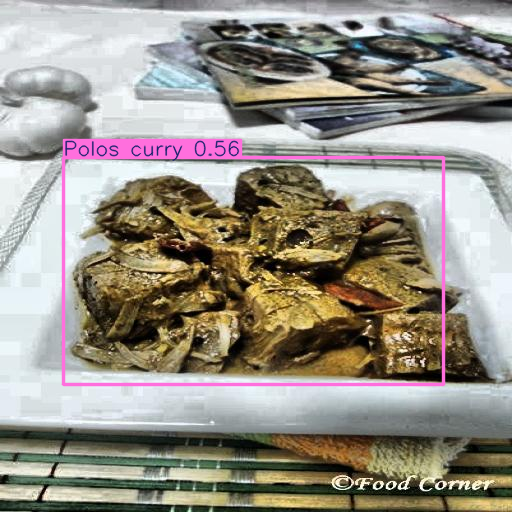


Detected 1 objects:
  - Polos curry: 0.56

EXPECTED IMPROVEMENTS WITH DETAIL SETTINGS:
✓ Better detection of small foods (sprats, rice grains)
✓ Improved boundaries between overlapping curries
✓ Higher mAP50-95 (better localization)
✓ Better performance on yellow rice, sweets, and papadam

Compare results with previous versions to see improvement!


In [18]:
# Step 0: Install packages
!pip install ultralytics roboflow --quiet

# Step 1: Upload your dataset ZIP
from google.colab import files
uploaded = files.upload()  # choose your ZIP file

# Step 2: Unzip the dataset
import zipfile
import os
for fn in uploaded.keys():
    with zipfile.ZipFile(fn, 'r') as zip_ref:
        zip_ref.extractall(fn.replace(".zip",""))

dataset_path = fn.replace(".zip","")
print("Dataset ready at:", dataset_path)

# Step 3: Train YOLOv8 model with DETAILED LEARNING settings
from ultralytics import YOLO

# Use yolov8s.pt for good balance of speed and accuracy
model = YOLO("yolov8s.pt")

# DETAILED LEARNING settings for better food detail detection
model.train(
    data=f"{dataset_path}/data.yaml",

    # Core settings - increased for better detail learning
    epochs=100,                          # More epochs to learn fine details
    imgsz=640,                           # Keep 640 (good balance for Colab)
    batch=4,                              # Keep small for Colab free

    # Project settings
    project="meal_plate_test",
    name="detail_learning",
    exist_ok=True,
    device=0,

    # CRITICAL: Augmentations for learning food details
    hsv_h=0.015,          # Hue augmentation (handles lighting variations)
    hsv_s=0.7,             # Saturation augmentation (curry color variations)
    hsv_v=0.4,             # Value augmentation (brightness variations)
    degrees=10.0,          # Small rotation (food doesn't rotate much)
    translate=0.1,         # Small translation (position variations)
    scale=0.5,             # Scale augmentation (different food sizes - critical!)
    shear=2.0,             # Small shear (perspective variations)
    perspective=0.0001,    # Slight perspective changes (plate angles)
    flipud=0.0,            # Don't flip upside down (food should be right-side up)
    fliplr=0.5,            # Horizontal flip (good for symmetrical foods)

    # Advanced augmentations for small details
    mosaic=1.0,            # Mosaic augmentation (helps with context)
    mixup=0.2,             # Mixup augmentation (helps with overlapping foods)
    copy_paste=0.3,        # Copy-paste augmentation (EXCELLENT for small foods like sprats, rice!)

    # Close mosaic in later epochs to refine details
    close_mosaic=10,       # Disable mosaic in last 10 epochs for fine-tuning

    # Optimizer settings
    optimizer='AdamW',      # Better for detail learning than SGD
    lr0=0.0005,             # Lower learning rate for fine details (was 0.01)
    lrf=0.01,               # Final learning rate factor
    momentum=0.937,         # Momentum
    weight_decay=0.0005,    # Regularization to prevent overfitting

    # Training strategy
    warmup_epochs=3,        # Warmup epochs
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,

    # Loss weights
    box=7.5,                 # Box loss weight (localization)
    cls=0.5,                 # Class loss weight (classification)
    dfl=1.5,                 # DFL loss weight (distribution focal loss)

    # Other helpful settings
    patience=20,             # Early stopping if no improvement
    save=True,               # Save checkpoints
    save_period=10,          # Save every 10 epochs
    plots=True,              # Generate plots
    workers=4,               # Data loading workers
    seed=42,                 # For reproducibility
    deterministic=True       # Deterministic training
)

# Step 4: Display results
print("\n" + "="*50)
print("TRAINING COMPLETE!")
print("="*50)

# Find best model path
best_model_path = f"/content/runs/detect/meal_plate_test/detail_learning/weights/best.pt"
print(f"Best model saved at: {best_model_path}")

# Step 5: Test on one example image
import random
valid_images_dir = os.path.join(dataset_path, "valid/images")
if os.path.exists(valid_images_dir):
    all_images = os.listdir(valid_images_dir)
    if all_images:
        # Pick a random validation image
        example_image = os.path.join(valid_images_dir, random.choice(all_images))
        print(f"\nTesting on random validation image: {example_image}")

        # Load best model and predict
        best_model = YOLO(best_model_path)
        results = best_model.predict(example_image, conf=0.25)  # Lower confidence to see more detections

        # Show results
        results[0].show()

        # Print detection stats
        if results[0].boxes:
            print(f"\nDetected {len(results[0].boxes)} objects:")
            for box in results[0].boxes:
                class_id = int(box.cls[0])
                class_name = results[0].names[class_id]
                confidence = float(box.conf[0])
                print(f"  - {class_name}: {confidence:.2f}")
        else:
            print("\nNo objects detected (try lowering confidence threshold)")
    else:
        print("No validation images found")
else:
    print("Validation directory not found")

# Step 6: Print final metrics (from training log)
print("\n" + "="*50)
print("EXPECTED IMPROVEMENTS WITH DETAIL SETTINGS:")
print("="*50)
print("✓ Better detection of small foods (sprats, rice grains)")
print("✓ Improved boundaries between overlapping curries")
print("✓ Higher mAP50-95 (better localization)")
print("✓ Better performance on yellow rice, sweets, and papadam")
print("\nCompare results with previous versions to see improvement!")

Testing on: ro4_jpg.rf.d51ace4ee9787ca96c1f6121237dad0a.jpg

image 1/1 /content/food detect.v17-no_augs.yolov8 (1)/valid/images/ro4_jpg.rf.d51ace4ee9787ca96c1f6121237dad0a.jpg: 640x640 2 Cocount rotis, 1 Dhal Curry, 16.3ms
Speed: 3.1ms preprocess, 16.3ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


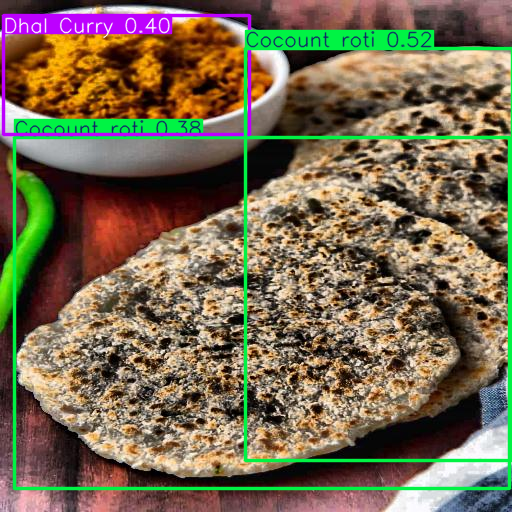

In [19]:
import random
import os

# Pick a random image from your validation set
valid_images_dir = os.path.join(dataset_path, "valid/images")
random_image = random.choice(os.listdir(valid_images_dir))
example_image = os.path.join(valid_images_dir, random_image)

print("Testing on:", random_image)
results = model.predict(example_image)
results[0].show()


Upload new meal plate images (you can select multiple):


Saving tt3.webp to tt3.webp
Saving tt4.jpg to tt4.jpg
Saving tt5.jpg to tt5 (1).jpg
Saving tt6.webp to tt6 (1).webp
Saving tt7.webp to tt7 (1).webp
5 image(s) uploaded for testing.

--- Testing: new_food_images/tt3.webp ---

image 1/1 /content/new_food_images/tt3.webp: 480x640 1 yellow rice, 13.6ms
Speed: 2.3ms preprocess, 13.6ms inference, 1.2ms postprocess per image at shape (1, 3, 480, 640)

image 1/1 /content/new_food_images/tt3.webp: 480x640 1 yellow rice, 12.8ms
Speed: 2.2ms preprocess, 12.8ms inference, 1.1ms postprocess per image at shape (1, 3, 480, 640)


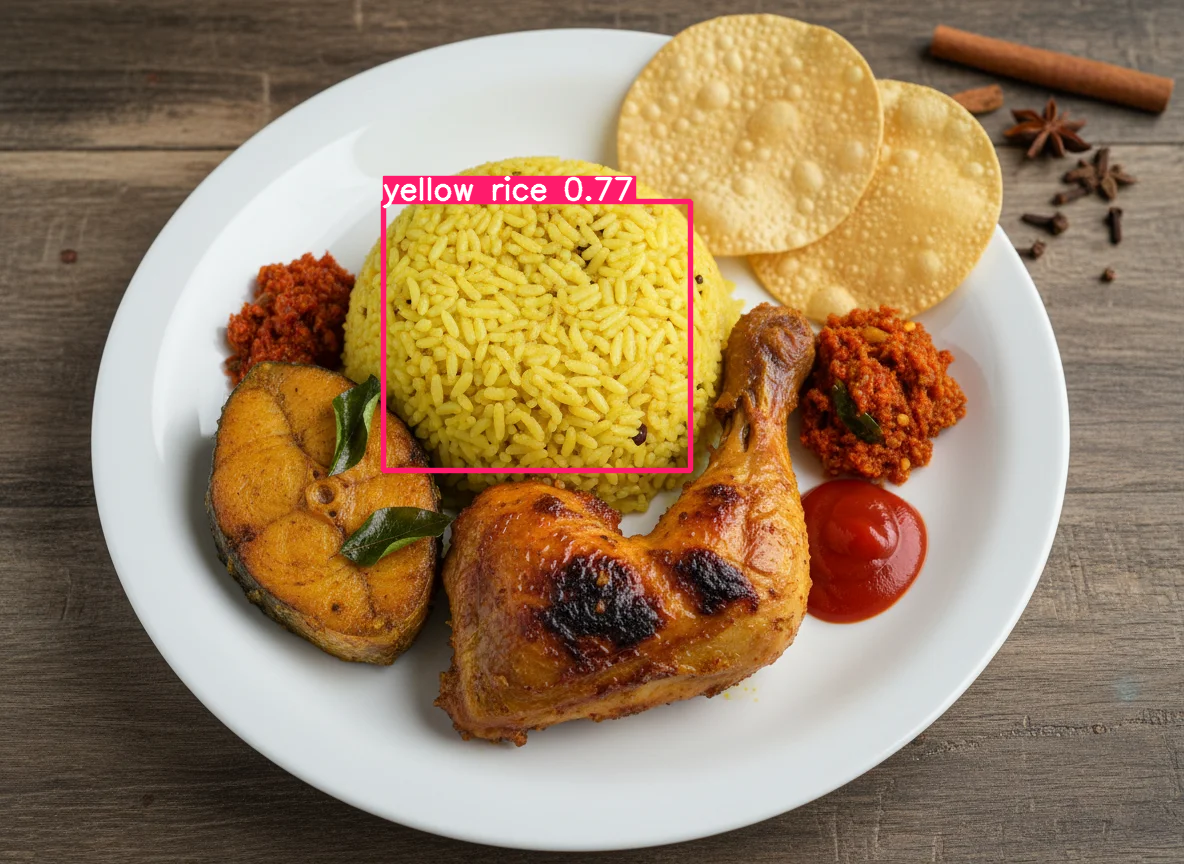

Detected foods:
  - yellow rice, Confidence: 0.77

--- Testing: new_food_images/tt4.jpg ---

image 1/1 /content/new_food_images/tt4.jpg: 448x640 (no detections), 14.0ms
Speed: 2.6ms preprocess, 14.0ms inference, 0.8ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/tt4.jpg: 448x640 (no detections), 12.9ms
Speed: 4.0ms preprocess, 12.9ms inference, 0.9ms postprocess per image at shape (1, 3, 448, 640)


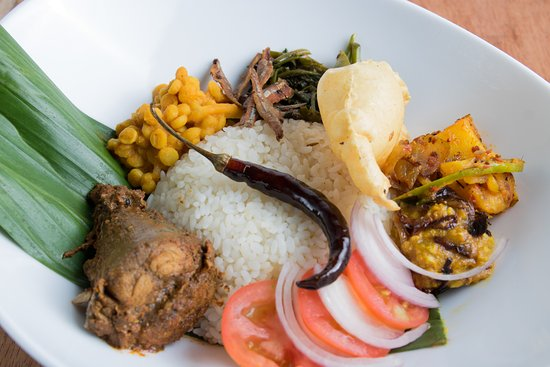

Detected foods:

--- Testing: new_food_images/tt5 (1).jpg ---

image 1/1 /content/new_food_images/tt5 (1).jpg: 448x640 1 Dhal Curry, 1 rice, 12.9ms
Speed: 3.9ms preprocess, 12.9ms inference, 2.0ms postprocess per image at shape (1, 3, 448, 640)

image 1/1 /content/new_food_images/tt5 (1).jpg: 448x640 1 Dhal Curry, 1 rice, 12.8ms
Speed: 3.5ms preprocess, 12.8ms inference, 1.7ms postprocess per image at shape (1, 3, 448, 640)


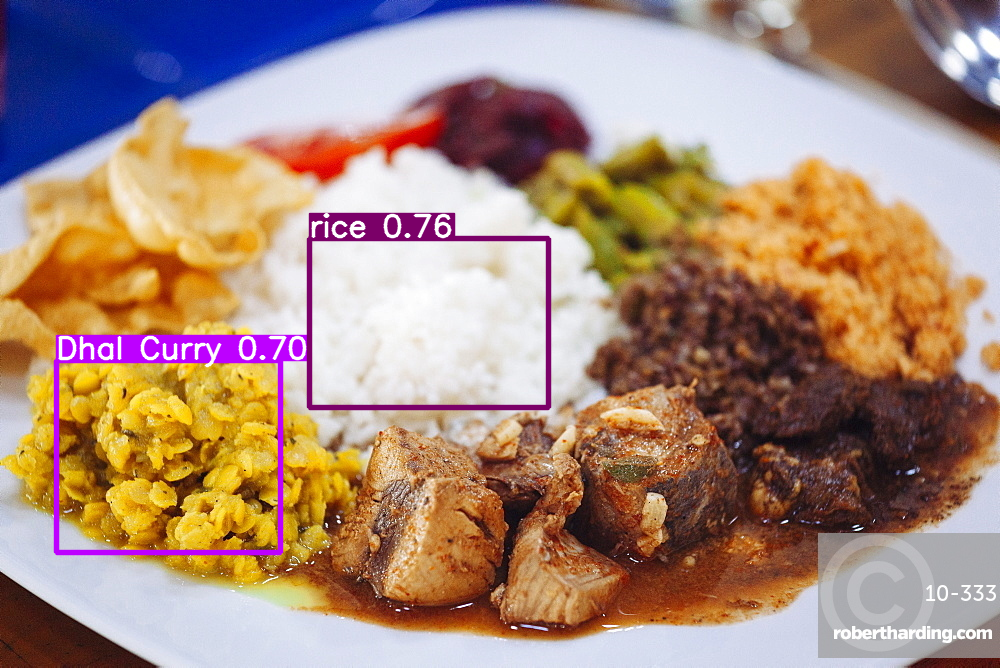

Detected foods:
  - rice, Confidence: 0.76
  - Dhal Curry, Confidence: 0.70

--- Testing: new_food_images/tt6 (1).webp ---

image 1/1 /content/new_food_images/tt6 (1).webp: 608x640 1 Carrot, 2 Gotukola Mallums, 1 Red rice, 1 rice, 17.2ms
Speed: 2.1ms preprocess, 17.2ms inference, 1.9ms postprocess per image at shape (1, 3, 608, 640)

image 1/1 /content/new_food_images/tt6 (1).webp: 608x640 1 Carrot, 2 Gotukola Mallums, 1 Red rice, 1 rice, 16.0ms
Speed: 2.2ms preprocess, 16.0ms inference, 1.7ms postprocess per image at shape (1, 3, 608, 640)


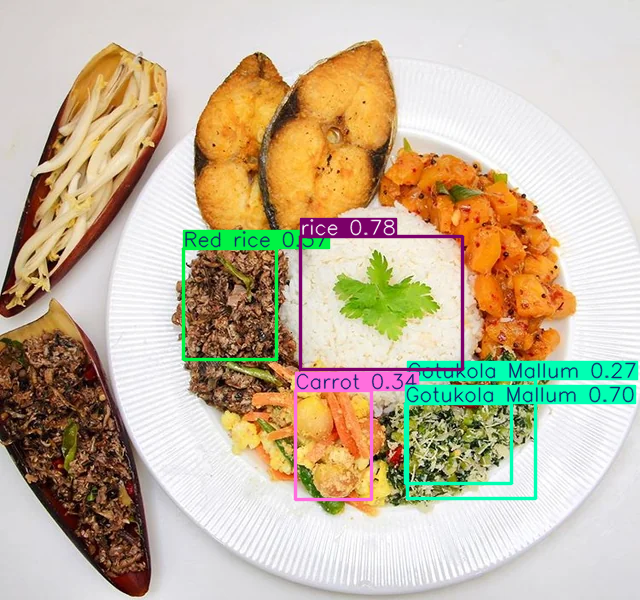

Detected foods:
  - rice, Confidence: 0.78
  - Gotukola Mallum, Confidence: 0.70
  - Red rice, Confidence: 0.37
  - Carrot, Confidence: 0.34
  - Gotukola Mallum, Confidence: 0.27

--- Testing: new_food_images/tt7 (1).webp ---

image 1/1 /content/new_food_images/tt7 (1).webp: 640x640 1 Dhal Curry, 2 Papadams, 2 rices, 17.3ms
Speed: 3.8ms preprocess, 17.3ms inference, 1.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/new_food_images/tt7 (1).webp: 640x640 1 Dhal Curry, 2 Papadams, 2 rices, 16.3ms
Speed: 4.8ms preprocess, 16.3ms inference, 1.7ms postprocess per image at shape (1, 3, 640, 640)


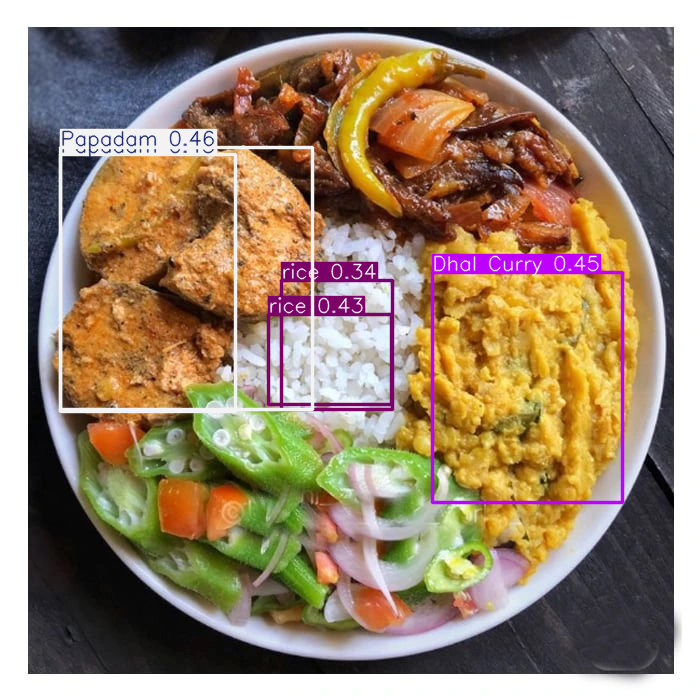

Detected foods:
  - Papadam, Confidence: 0.46
  - Papadam, Confidence: 0.45
  - Dhal Curry, Confidence: 0.45
  - rice, Confidence: 0.43
  - rice, Confidence: 0.34


In [20]:
# ==========================
# Cell 3: Test on new/unseen images
# ==========================

from ultralytics import YOLO
from google.colab import files
import os

# 1️⃣ Load your trained YOLOv8 model
model = YOLO("/content/runs/detect/meal_plate_test/quick_train/weights/best.pt")

# 2️⃣ Upload one or more new images (simulate user uploads)
print("Upload new meal plate images (you can select multiple):")
uploaded = files.upload()  # user selects image files

# 3️⃣ Create a folder to save uploaded images
os.makedirs("new_food_images", exist_ok=True)

# Save uploaded images
uploaded_files = []
for filename in uploaded.keys():
    path = os.path.join("new_food_images", filename)
    uploaded_files.append(path)
    with open(path, "wb") as f:
        f.write(uploaded[filename])
print(f"{len(uploaded_files)} image(s) uploaded for testing.")

# 4️⃣ Run predictions on each uploaded image
for img_path in uploaded_files:
    print("\n--- Testing:", img_path, "---")
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results = model.predict(img_path)  # Run YOLO detection

    # Show the image with bounding boxes
    results[0].show()

    # Print detected foods with confidence scores
    print("Detected foods:")
    for box in results[0].boxes:
        class_id = int(box.cls[0])
        confidence = float(box.conf[0])
        class_name = model.names[class_id]
        print(f"  - {class_name}, Confidence: {confidence:.2f}")
